In [37]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
%matplotlib inline
warnings.filterwarnings('ignore')

In [38]:
train = pd.read_csv(r"C:\Users\KIIT\Downloads\test (1).csv")
test = pd.read_csv(r"C:\Users\KIIT\Downloads\train (3).csv")

# To know number of columns and rows
train.shape
# (891, 12)

(418, 11)

In [39]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [40]:
train.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

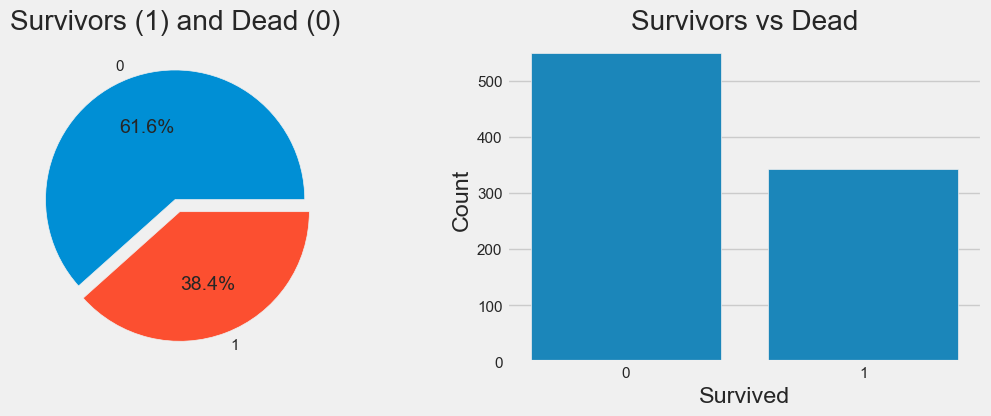

In [42]:
f, ax = plt.subplots(1, 2, figsize=(12, 4)) 

train_data['Survived'].value_counts().plot.pie(
    explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=False)

ax[0].set_title('Survivors (1) and Dead (0)')
ax[0].set_ylabel('')

import seaborn as sns
sns.countplot(x='Survived', data=train_data, ax=ax[1])

ax[1].set_ylabel('Count')
ax[1].set_title('Survivors vs Dead')

plt.show()

Train shape: (891, 12)
Test shape: (418, 11)
Columns in train: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Surv

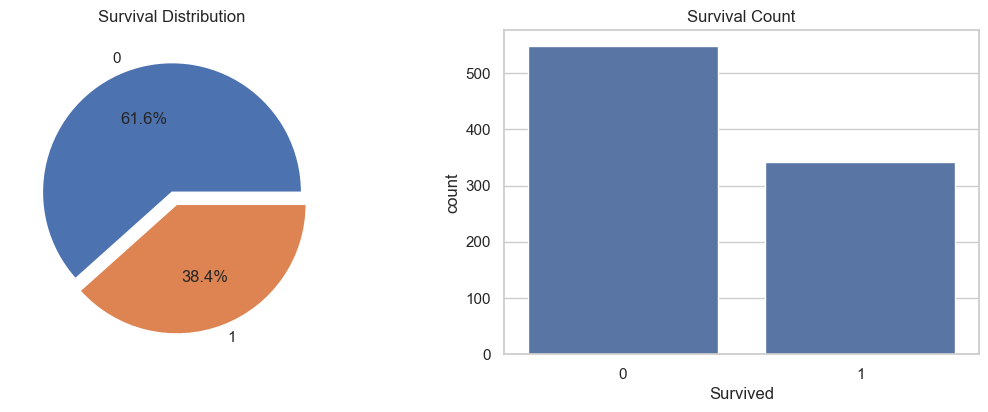

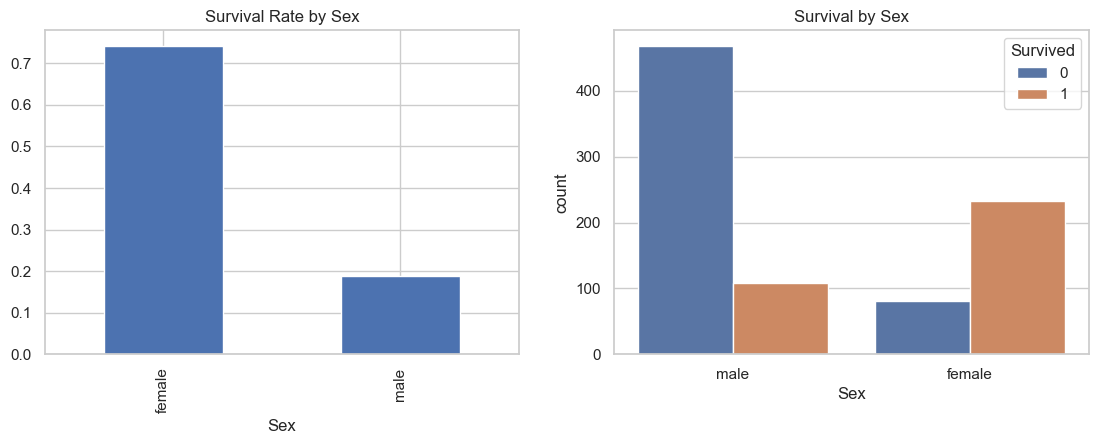

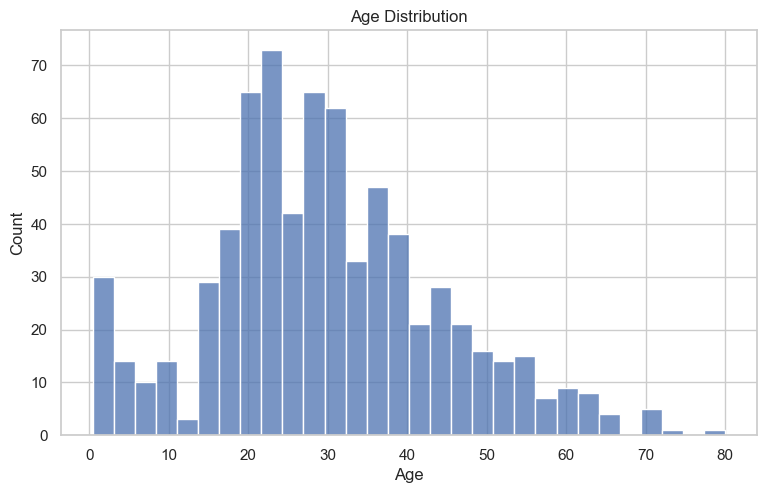

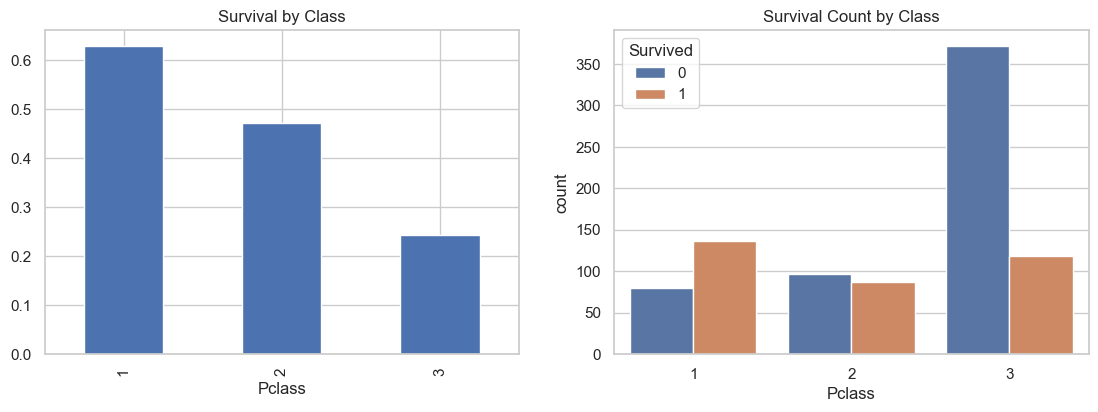

Validation Accuracy: 0.8212290502793296


OSError: [Errno 28] No space left on device

In [46]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ==============================
# 2. LOAD CORRECT DATA (FIXED)
# ==============================
train = pd.read_csv(r"C:\Users\KIIT\Downloads\train (3).csv")   # ✅ TRAIN
test  = pd.read_csv(r"C:\Users\KIIT\Downloads\test (1).csv")    # ✅ TEST

print("Train shape:", train.shape)
print("Test shape:", test.shape)

# 🔍 Verify
print("Columns in train:", train.columns)

# ==============================
# 3. BASIC INFO
# ==============================
print(train.info())
print(train.isnull().sum())

# ==============================
# 4. EDA VISUALIZATIONS
# ==============================

# --- Survival Distribution ---
f, ax = plt.subplots(1, 2, figsize=(12, 4))

train['Survived'].value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%',
    ax=ax[0]
)
ax[0].set_title('Survival Distribution')
ax[0].set_ylabel('')

sns.countplot(x='Survived', data=train, ax=ax[1])
ax[1].set_title('Survival Count')

plt.show()


# --- Survival by Sex ---
f, ax = plt.subplots(1, 2, figsize=(12, 4))

train.groupby('Sex')['Survived'].mean().plot.bar(ax=ax[0])
ax[0].set_title('Survival Rate by Sex')

sns.countplot(x='Sex', hue='Survived', data=train, ax=ax[1])
ax[1].set_title('Survival by Sex')

plt.show()


# --- Age Distribution ---
plt.figure(figsize=(8,5))
sns.histplot(train['Age'].dropna(), bins=30)
plt.title("Age Distribution")
plt.show()


# --- Class vs Survival ---
f, ax = plt.subplots(1, 2, figsize=(12, 4))

train.groupby('Pclass')['Survived'].mean().plot.bar(ax=ax[0])
ax[0].set_title('Survival by Class')

sns.countplot(x='Pclass', hue='Survived', data=train, ax=ax[1])
ax[1].set_title('Survival Count by Class')

plt.show()


# ==============================
# 5. FEATURE ENGINEERING
# ==============================

# Family size
train['FamilySize'] = train['SibSp'] + train['Parch']
test['FamilySize'] = test['SibSp'] + test['Parch']

# Fill missing values
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

train['Fare'].fillna(train['Fare'].median(), inplace=True)
test['Fare'].fillna(test['Fare'].median(), inplace=True)

train['Embarked'].fillna('S', inplace=True)
test['Embarked'].fillna('S', inplace=True)

# Convert categorical → numeric
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

train['Embarked'] = train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test['Embarked'] = test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Final NaN safety
train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

# ==============================
# 6. MODEL BUILDING
# ==============================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

features = ['Sex', 'Age', 'Pclass', 'Fare', 'Embarked', 'FamilySize']

X = train[features]
y = train['Survived']

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Validation
y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", accuracy)

# ==============================
# 7. TRAIN FULL MODEL
# ==============================
model.fit(X, y)

# ==============================
# 8. PREDICT TEST
# ==============================
test_predictions = model.predict(test[features])

# ==============================
# 9. SUBMISSION FILE
# ==============================
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('kaggle_submission.csv', index=False)

print("✅ SUCCESS: File saved as kaggle_submission.csv")


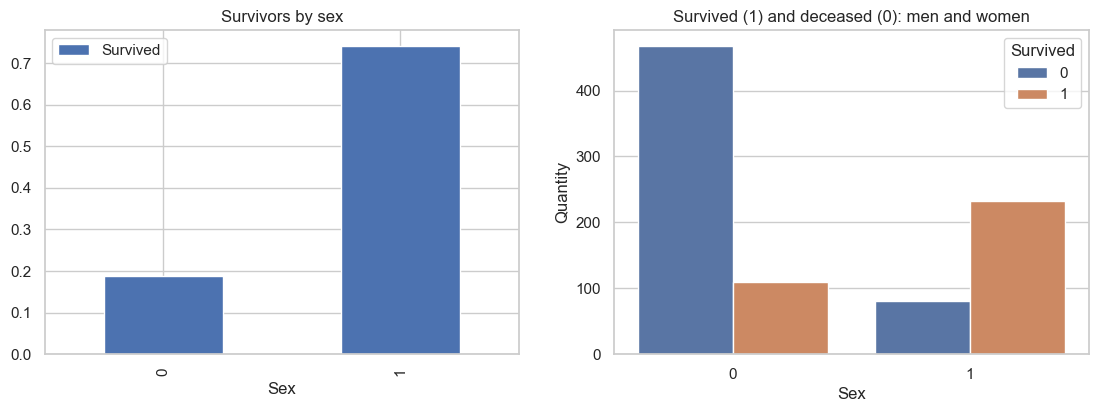

In [47]:
f, ax = plt.subplots(1, 2, figsize=(12, 4)) 
train[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0]) 
ax[0].set_title('Survivors by sex') 
sns.countplot(x='Sex', hue='Survived', data=train, ax=ax[1])
ax[1].set_ylabel('Quantity') 
ax[1].set_title('Survived (1) and deceased (0): men and women') 
plt.show()

In [48]:
#Feature Engineering: Optimizing Data for Model Training
#This section focuses on refining the dataset by removing irrelevant features and transforming categorical data into numerical formats. Key tasks include:
#Dropping Redundant Features: Removing columns like Cabin that offer limited predictive value.
#Creating New Features: Introducing a new column to indicate whether cabin information was assigned or not.
#Data Transformation: Converting textual data into numerical categories for seamless model training.
train = train.drop(['Cabin'], axis=1)
test = test.drop(['Cabin'], axis=1)

In [49]:
train = train.drop(['Ticket'], axis=1)
test = test.drop(['Ticket'], axis=1)

In [50]:
# replacing the missing values in 
# the Embarked feature with S
train = train.fillna({"Embarked": "S"})

In [51]:
# sort the ages into logical categories
train["Age"] = train["Age"].fillna(-0.5)
test["Age"] = test["Age"].fillna(-0.5)
bins = [-1, 0, 5, 12, 18, 24, 35, 60, np.inf]
labels = ['Unknown', 'Baby', 'Child', 'Teenager',
          'Student', 'Young Adult', 'Adult', 'Senior']
train['AgeGroup'] = pd.cut(train["Age"], bins, labels=labels)
test['AgeGroup'] = pd.cut(test["Age"], bins, labels=labels)

In [52]:
# create a combined group of both datasets
combine = [train, test]

# extract a title for each Name in the 
# train and test datasets
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

pd.crosstab(train['Title'], train['Sex'])

# replace various titles with more common names
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Capt', 'Col',
                                                 'Don', 'Dr', 'Major',
                                                 'Rev', 'Jonkheer', 'Dona'],
                                                'Rare')

    dataset['Title'] = dataset['Title'].replace(
        ['Countess', 'Lady', 'Sir'], 'Royal')
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

train[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

# map each of the title groups to a numerical value
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3,
                 "Master": 4, "Royal": 5, "Rare": 6}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

In [53]:
mr_age = train[train["Title"] == 1]["AgeGroup"].mode()  # Young Adult
miss_age = train[train["Title"] == 2]["AgeGroup"].mode()  # Student
mrs_age = train[train["Title"] == 3]["AgeGroup"].mode()  # Adult
master_age = train[train["Title"] == 4]["AgeGroup"].mode()  # Baby
royal_age = train[train["Title"] == 5]["AgeGroup"].mode()  # Adult
rare_age = train[train["Title"] == 6]["AgeGroup"].mode()  # Adult

age_title_mapping = {1: "Young Adult", 2: "Student",
                     3: "Adult", 4: "Baby", 5: "Adult", 6: "Adult"}

for x in range(len(train["AgeGroup"])):
    if train["AgeGroup"][x] == "Unknown":
        train["AgeGroup"][x] = age_title_mapping[train["Title"][x]]

for x in range(len(test["AgeGroup"])):
    if test["AgeGroup"][x] == "Unknown":
        test["AgeGroup"][x] = age_title_mapping[test["Title"][x]]

In [54]:
from sklearn.model_selection import train_test_split

# Drop the Survived and PassengerId
# column from the trainset
predictors = train.drop(['Survived', 'PassengerId'], axis=1)
target = train["Survived"]
x_train, x_val, y_train, y_val = train_test_split(
    predictors, target, test_size=0.2, random_state=0)

In [56]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==============================
# LOAD DATA
# ==============================
train = pd.read_csv(r"C:\Users\KIIT\Downloads\train (3).csv")

# ==============================
# FEATURE ENGINEERING
# ==============================

# Drop useless string columns
train = train.drop(['Name', 'Ticket', 'Cabin'], axis=1)

# Fill missing values
train['Age'] = train['Age'].fillna(train['Age'].median())
train['Embarked'] = train['Embarked'].fillna('S')

# Convert categorical → numeric
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
train['Embarked'] = train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Create new feature
train['FamilySize'] = train['SibSp'] + train['Parch']

# Drop PassengerId (not useful for training)
train = train.drop(['PassengerId'], axis=1)

# Final safety
train = train.fillna(0)

# ==============================
# SPLIT DATA
# ==============================
X = train.drop('Survived', axis=1)
y = train['Survived']

x_train, x_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# MODEL
# ==============================
model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(x_train, y_train)

# ==============================
# EVALUATION
# ==============================
y_pred = model.predict(x_val)

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 81.56 %
